In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df1 = pd.read_csv('errors__with_1_new_eqn_rho_100.0_4.csv')
df2 = pd.read_csv('errors__with_1_new_eqn_rho_10000.0_4.csv')
df3 = pd.read_csv('errors__with_2_new_eqn_rho_100.0_4.csv')
df4 = pd.read_csv('errors__with_2_new_eqn_rho_10000.0_4.csv')
df5 = pd.read_csv('errors__with_3_new_eqn_rho_100.0_4.csv')
df6 = pd.read_csv('errors__with_3_new_eqn_rho_10000.0_4.csv')
df7 = pd.read_csv('errors__with_new_eqn_rho_100.0_4.csv')
df8 = pd.read_csv('errors__with_new_eqn_rho_10000.0_4.csv')

In [ ]:
df_a = pd.read_csv('errors_with_1_new_eqn_no_split_4.csv')
df_b = pd.read_csv('errors_with_1_new_eqn_corner_split_4.csv')
df_c = pd.read_csv('errors_with_1_new_eqn_all_split_4.csv')
df_d = pd.read_csv('errors_with_2_new_eqn_all_split_4.csv')
df_e = pd.read_csv('errors_with_3_new_eqn_all_split_4.csv')
df_f = pd.read_csv('errors_with_new_eqn_all_split_4.csv')

In [ ]:
df1

,meshsize,h,Time,iter,L2 error uh,H1 error uh,L2 div uh,abs L2 error ph
0,4,1.767767,9.366800,10,4.849713e-01,3.678437,2.425358e-08,7.832252
1,8,0.950180,13.126427,10,2.168340e-02,0.342021,1.450700e-08,0.952911
2,16,0.494111,19.022308,10,7.753569e-04,0.025138,2.535860e-09,0.069100
3,32,0.238444,75.679304,10,2.362988e-05,0.001562,1.023882e-10,0.004096
4,64,0.119322,290.570859,10,7.168265e-07,0.000096,7.977195e-12,0.000241


In [ ]:
df_a

,iter,L2 error uh,H1 error uh,L2 div uh,abs L2 error ph
0,1,0.006990,0.041326,0.029636,0.078502
1,2,0.000790,0.025235,0.000433,0.076157
2,3,0.000792,0.025488,0.000109,0.078787
3,4,0.000795,0.025550,0.000103,0.080790
4,5,0.000795,0.025568,0.000102,0.083453
5,6,0.000796,0.025574,0.000102,0.087056
6,7,0.000796,0.025576,0.000102,0.091592
7,8,0.000796,0.025577,0.000102,0.096963
8,9,0.000796,0.025577,0.000102,0.103049
9,10,0.000796,0.025577,0.000102,0.109736


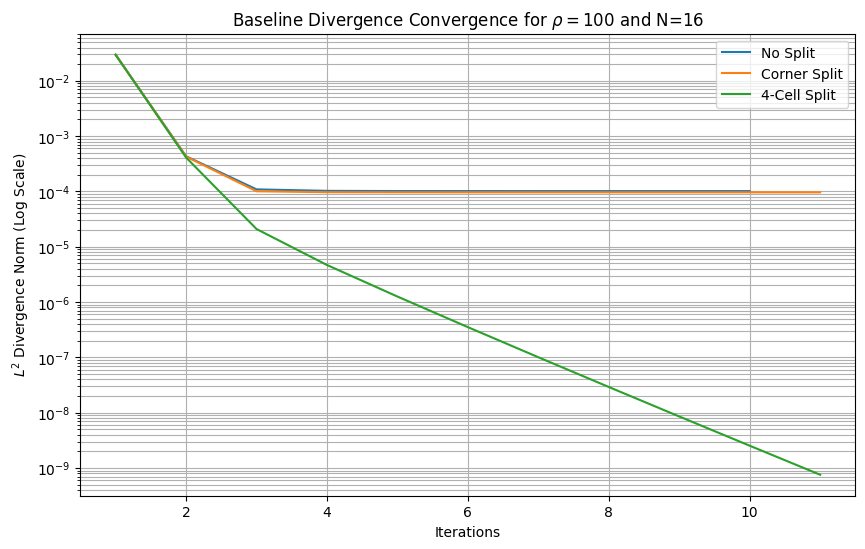

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(df_a['iter'], df_a['L2 div uh'], label='No Split')
plt.plot(df_b['iter'], df_b['L2 div uh'], label='Corner Split')
plt.plot(df_c['iter'], df_c['L2 div uh'], label='4-Cell Split')

plt.yscale('log')
plt.xlabel('Iterations')
plt.ylabel('$L^2$ Divergence Norm (Log Scale)')
plt.title(r'Baseline Divergence Convergence for $\rho=100$ and N=16')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.savefig('baseline_divergence_convergence.png')
plt.show()

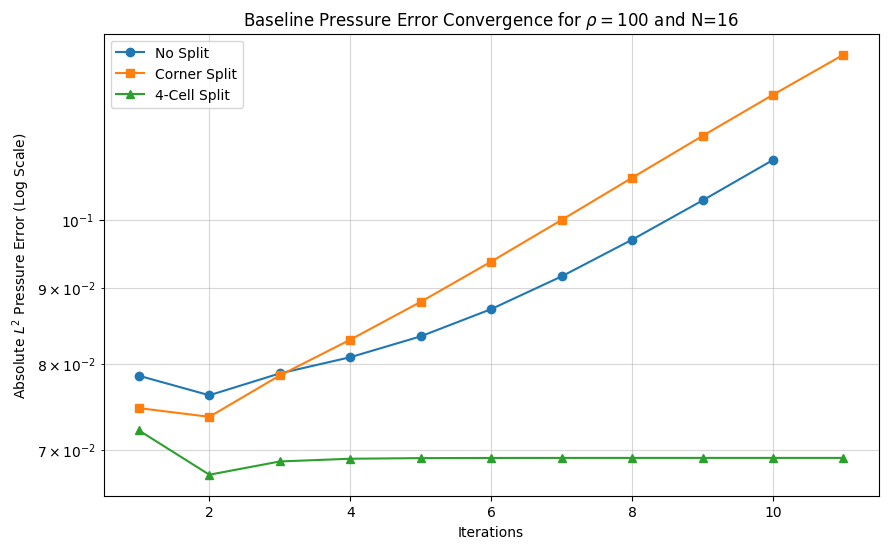

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(df_a['iter'], df_a['abs L2 error ph'], 'o-', label='No Split')
plt.plot(df_b['iter'], df_b['abs L2 error ph'], 's-', label='Corner Split')
plt.plot(df_c['iter'], df_c['abs L2 error ph'], '^-', label='4-Cell Split')

plt.yscale('log')
plt.xlabel('Iterations')
plt.ylabel('Absolute $L^2$ Pressure Error (Log Scale)')
plt.title(r'Baseline Pressure Error Convergence for $\rho=100$ and N=16')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.savefig('baseline_pressure_convergence.png')
plt.show()

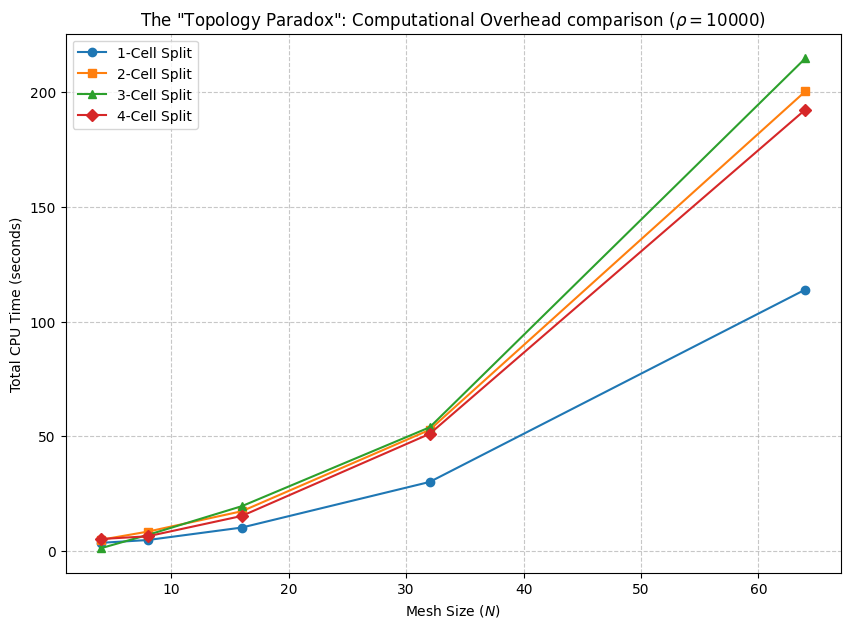

In [ ]:
plt.figure(figsize=(10, 7))

# Using rho=10000 data
# df2: 1-cell, df4: 2-cell, df6: 3-cell, df8: 4-cell
plt.plot(df2['meshsize'], df2['Time'], 'o-', label='1-Cell Split')
plt.plot(df4['meshsize'], df4['Time'], 's-', label='2-Cell Split')
plt.plot(df6['meshsize'], df6['Time'], '^-', label='3-Cell Split')
plt.plot(df8['meshsize'], df8['Time'], 'D-', label='4-Cell Split')

plt.xlabel('Mesh Size ($N$)')
plt.ylabel('Total CPU Time (seconds)')
plt.title(r'The "Topology Paradox": Computational Overhead comparison ($\rho=10000$)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.savefig('topology_paradox.png')
plt.show()

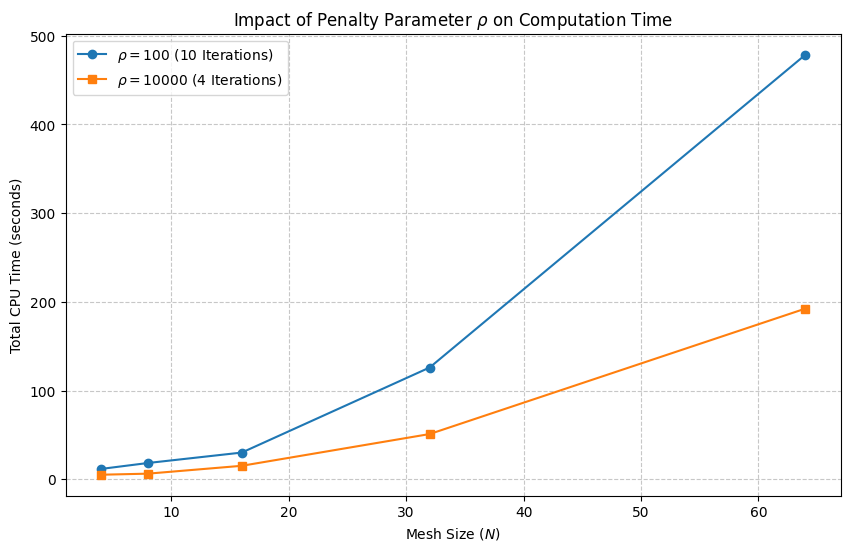

In [ ]:
plt.figure(figsize=(10, 6))

# df7: rho=100, 4-cell split (iter=10)
# df8: rho=10000, 4-cell split (iter=4)
plt.plot(df7['meshsize'], df7['Time'], 'o-', label=r'$\rho=100$ (10 Iterations)')
plt.plot(df8['meshsize'], df8['Time'], 's-', label=r'$\rho=10000$ (4 Iterations)')

plt.xlabel('Mesh Size ($N$)')
plt.ylabel('Total CPU Time (seconds)')
plt.title(r'Impact of Penalty Parameter $\rho$ on Computation Time')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.savefig('rho_impact_time.png')
plt.show()

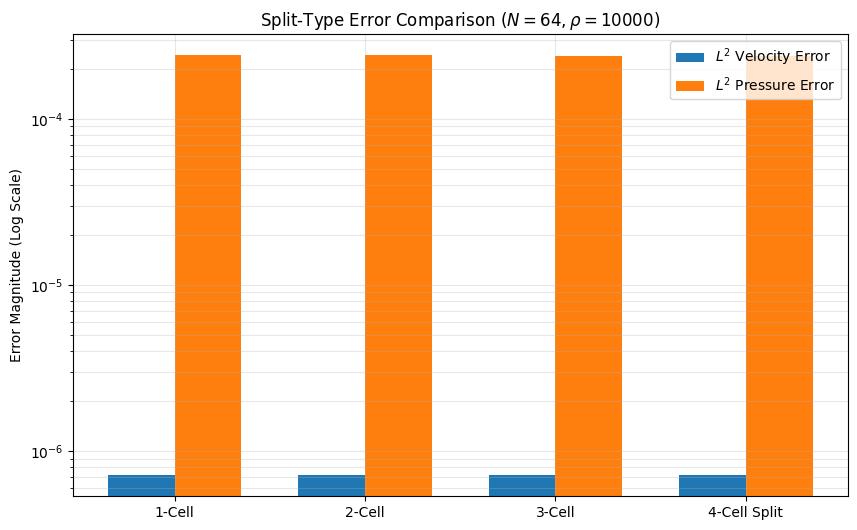

In [ ]:
import numpy as np

# Extracting the last row (N=64) for each split type at rho=10000
# df2: 1-cell, df4: 2-cell, df6: 3-cell, df8: 4-cell (based on file names and context)
labels = ['1-Cell', '2-Cell', '3-Cell', '4-Cell Split']
vel_errors = [df2['L2 error uh'].iloc[-1], df4['L2 error uh'].iloc[-1], df6['L2 error uh'].iloc[-1], df8['L2 error uh'].iloc[-1]]
pres_errors = [df2['abs L2 error ph'].iloc[-1], df4['abs L2 error ph'].iloc[-1], df6['abs L2 error ph'].iloc[-1], df8['abs L2 error ph'].iloc[-1]]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, vel_errors, width, label='$L^2$ Velocity Error')
rects2 = ax.bar(x + width/2, pres_errors, width, label='$L^2$ Pressure Error')

ax.set_yscale('log')
ax.set_ylabel('Error Magnitude (Log Scale)')
ax.set_title(r'Split-Type Error Comparison ($N=64, \rho=10000$)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(True, which="both", ls="-", alpha=0.3)

plt.savefig('split_type_comparison.png')
plt.show()

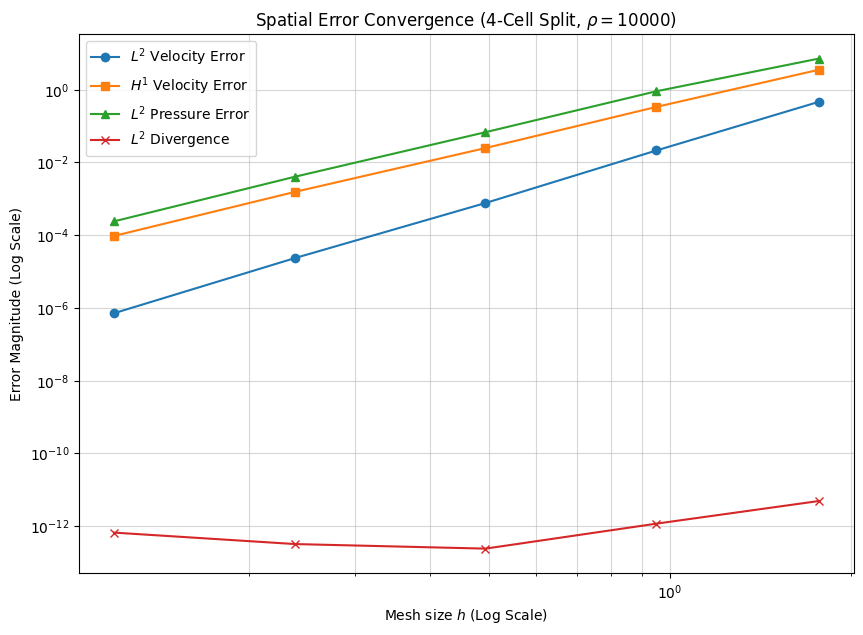

In [ ]:
plt.figure(figsize=(10, 7))

# Using df6 which corresponds to the 4-cell split at rho=10000
plt.plot(df6['h'], df6['L2 error uh'], 'o-', label='$L^2$ Velocity Error')
plt.plot(df6['h'], df6['H1 error uh'], 's-', label='$H^1$ Velocity Error')
plt.plot(df6['h'], df6['abs L2 error ph'], '^-', label='$L^2$ Pressure Error')
plt.plot(df6['h'], df6['L2 div uh'], 'x-', label='$L^2$ Divergence')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Mesh size $h$ (Log Scale)')
plt.ylabel('Error Magnitude (Log Scale)')
plt.title(r'Spatial Error Convergence (4-Cell Split, $\rho=10000$)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

# Optional: Annotate slopes for convergence rates
plt.savefig('spatial_error_convergence.png')
plt.show()